In [1]:
from functools import partial
import numpy as np
import jax
import jax.numpy as jnp
from jax import vmap, jit
from jax_helpers import gg_space, glob_inh, sigmoid, softmax
from jax_scaffold_theta import Scaffold_theta, compute_sample_step
from jax_scaffold_thetah import Scaffold
from tqdm import tqdm
import matplotlib.pyplot as plt
jax.config.update('jax_default_matmul_precision', 'highest')
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

# Freq, duty search (Only theta_h)

In [9]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)
scaffold = Scaffold_theta(400, lambdas, 'sigmoid', gg_exc=1, gg_inh=-5, gamma=0.6)


g0_target = jnp.asarray(scaffold.grid)
h0        = jnp.asarray(scaffold.hc)
g0_init   = jnp.zeros_like(g0_target)      # start g at zero — this is the recall task
h0_norm   = jnp.linalg.norm(h0, axis=0)    # this is per pattern norm

freq_h_range = np.arange(0.0, 5.0, 0.1)
duty_h_range = np.arange(0.1, 1.1, 0.1)
FF, DD = np.meshgrid(freq_h_range, duty_h_range, indexing='ij')
freq_flat = jnp.asarray(FF.ravel())
duty_flat = jnp.asarray(DD.ravel())

vmapped_run = jax.jit(
    jax.vmap(
        Scaffold_theta.simulate_run_sampled,
        in_axes=(None, None, None, None, None, None, None, None, None, (0, None), (0, None), (None, None), None),
        #         g0    h0  weights lambdas b  tau_g tau_h activation dt  freq       duty       phase      n_steps
    ),
    static_argnames=('lambdas', 'activation', 'n_steps'))

def score_thetah(weights, chunk_size=200, n_steps=250, dt=0.1):
    grid_chunks, hc_chunks = [], []
    n = freq_flat.shape[0]
    for start in tqdm(range(0, n, chunk_size)):
        f_chunk = freq_flat[start:start + chunk_size]
        d_chunk = duty_flat[start:start + chunk_size]

        g_sampled, h_sampled = vmapped_run(
            g0_init, h0, weights, lambdas_static,
            scaffold.b, scaffold.tau_g, scaffold.tau_h, sigmoid, dt,
            (f_chunk, 1.0), (d_chunk, 1.0), (0.0, 0.0), n_steps,
        )

        grid_err = jnp.max(jnp.abs(g_sampled - g0_target[None]), axis=1)          # (chunk, patts)
        hc_err   = jnp.linalg.norm(h_sampled - h0[None], axis=1) / h0_norm[None]  # (chunk, patts)

        grid_chunks.append(np.asarray(grid_err))
        hc_chunks.append(np.asarray(hc_err))

    grid_errors = np.concatenate(grid_chunks, axis=0).reshape(len(freq_h_range), len(duty_h_range), -1)
    hc_errors   = np.concatenate(hc_chunks, axis=0).reshape(len(freq_h_range), len(duty_h_range), -1)
    return grid_errors, hc_errors

In [10]:
grid_errors, hc_errors = score_thetah(scaffold.weights)

100%|██████████| 3/3 [00:26<00:00,  8.73s/it]


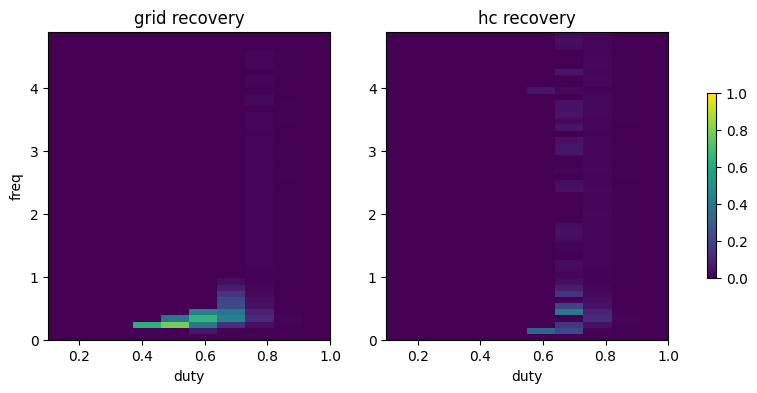

In [16]:
frac_grid = np.mean(grid_errors < 0.2, axis=-1)
frac_hc   = np.mean(hc_errors < 0.4, axis=-1)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(frac_grid, origin='lower', vmin=0, vmax=1,
                    extent=[duty_h_range[0], duty_h_range[-1], freq_h_range[0], freq_h_range[-1]], aspect='auto')
ax[0].set_xlabel('duty'); ax[0].set_ylabel('freq'); ax[0].set_title('grid recovery')
im1 = ax[1].imshow(frac_hc, origin='lower', vmin=0, vmax=1,
                    extent=[duty_h_range[0], duty_h_range[-1], freq_h_range[0], freq_h_range[-1]], aspect='auto')
ax[1].set_xlabel('duty'); ax[1].set_title('hc recovery')
fig.colorbar(im1, ax=ax, shrink=0.6)

In [12]:
flat_idx = np.argmax(frac_grid)
coords = np.unravel_index(flat_idx, frac_grid.shape)
print(coords)
print("Freq, duty for max grid recovery:", freq_h_range[coords[0]], duty_h_range[coords[1]])
print(np.max(frac_grid[1:, :-1]))

print(np.argmin(grid_errors[coords[0], coords[1], :]))

flat_idx = np.argmax(frac_hc)
coords = np.unravel_index(flat_idx, frac_hc.shape)
print(coords)
print("Freq, duty for max hc recovery:", freq_h_range[coords[0]], duty_h_range[coords[1]])
print(np.max(frac_hc[1:, :-1]))


(np.int64(2), np.int64(4))
Freq, duty for max grid recovery: 0.2 0.5
0.0019444444444444444 0.7825
3557
(np.int64(4), np.int64(6))
Freq, duty for max hc recovery: 0.4 0.7000000000000001
0.0019444444444444444 0.40166666666666667


# Parameter search (theta_h + theta_g)

In [17]:
def parameter_search_scored(scaffold, g0, h0, g_target, h_target, h_target_norm,
                             freq_h_vals, freq_g_vals, duty_h_vals, duty_g_vals,
                             phase_diff_vals, phase_h=0.0, n_steps=250,
                             grid_thresh=0.2, hc_thresh=0.4, chunk_size=500, show_progress=True):

    grids = np.meshgrid(
        np.asarray(freq_h_vals), np.asarray(freq_g_vals),
        np.asarray(duty_h_vals), np.asarray(duty_g_vals),
        np.asarray(phase_diff_vals), indexing='ij',
    )
    param_shape = grids[0].shape
    freq_h_flat, freq_g_flat, duty_h_flat, duty_g_flat, phase_diff_flat = (
        jnp.asarray(g.ravel()) for g in grids
    )
    phase_g_flat = phase_h + phase_diff_flat

    g0, h0 = jnp.asarray(g0), jnp.asarray(h0)
    g_target, h_target = jnp.asarray(g_target), jnp.asarray(h_target)
    h_target_norm = jnp.asarray(h_target_norm)


    vmapped_run = jax.jit(
        jax.vmap(
            Scaffold_theta.run_and_score,
            in_axes=(None, None, None, None, None, None, None, None, None,
                     (0, 0), (0, 0), (None, 0), None, None, None, None, None, None),
            #         g0    h0   weights lambdas  b   tau_g tau_h activation dt  freq    duty    phase       n_steps g_target h_target h_target_norm grid_thresh hc_thresh
        ),
        static_argnames=('lambdas', 'activation', 'n_steps'),
    )

    n = freq_h_flat.shape[0]
    grid_chunks, hc_chunks = [], []
    iterator = range(0, n, chunk_size)
    if show_progress:
        from tqdm import tqdm
        iterator = tqdm(iterator)

    for start in iterator:
        sl = slice(start, start + chunk_size)
        frac_grid_chunk, frac_hc_chunk = vmapped_run(
            g0, h0, scaffold.weights, scaffold.lambdas,
            scaffold.b, scaffold.tau_g, scaffold.tau_h, scaffold.activation, scaffold.dt,
            (freq_h_flat[sl], freq_g_flat[sl]),
            (duty_h_flat[sl], duty_g_flat[sl]),
            (phase_h, phase_g_flat[sl]),
            n_steps, g_target, h_target, h_target_norm, grid_thresh, hc_thresh,
        )
        grid_chunks.append(np.asarray(frac_grid_chunk))
        hc_chunks.append(np.asarray(frac_hc_chunk))

    frac_grid = np.concatenate(grid_chunks, axis=0).reshape(param_shape)
    frac_hc = np.concatenate(hc_chunks, axis=0).reshape(param_shape)
    return frac_grid, frac_hc


## 5D Search

In [18]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)
scaffold = Scaffold_theta(400, lambdas, 'sigmoid', gg_exc=5, gg_inh=-8.75, gamma=0.6)

g0_target = jnp.asarray(scaffold.grid)
h0        = jnp.asarray(scaffold.hc)
g0_init   = jnp.zeros_like(g0_target)
h0_norm   = jnp.linalg.norm(h0, axis=0)

freq_h_range = np.arange(0.0, 4.0, 0.25)
freq_g_range = np.arange(0.0, 4.0, 0.25)
duty_h_range = np.arange(0.1, 1.1, 0.2)
duty_g_range = np.arange(0.1, 1.1, 0.2)
phase_diff_range = np.arange(0.0, 1.1, 0.25)
phase_h = 0.0

In [ ]:
frac_grid, frac_hc = parameter_search_scored(
    scaffold, g0_init, h0, g0_target, h0, h0_norm,
    freq_h_range, freq_g_range, duty_h_range, duty_g_range, phase_diff_range,
    phase_h=phase_h,
    n_steps=250, chunk_size=200,
)

np.save('frac_grid_output.npy', frac_grid)
np.save('frac_hc_output.npy', frac_hc)

# frac_grid_output: (Fh, Fg, Dh, Dg, Pd), frac_hc_output: (Fh, Fg, Dh, Dg, Pd)
print(frac_grid.shape, frac_hc.shape)

 66%|██████▋   | 106/160 [13:25<06:49,  7.59s/it]

In [ ]:
frac_grid = np.load('frac_grid_output.npy')
frac_hc = np.load('frac_hc_output.npy')

In [ ]:
flat_idx = np.argmax(frac_grid)
coords = np.unravel_index(flat_idx, frac_grid.shape)
fh_i, fg_i, dh_i, dg_i, pd_i = coords
print('best (freq_h, freq_g, duty_h, duty_g, phase_diff) for grid recovery:')
print(freq_h_range[fh_i], freq_g_range[fg_i], duty_h_range[dh_i], duty_g_range[dg_i], phase_diff_range[pd_i])
print('recovery fraction (grid):', frac_grid[coords])
print('recovery fraction (hc):', frac_hc[coords])

flat_idx = np.argmax(frac_hc)
coords = np.unravel_index(flat_idx, frac_hc.shape)
fh_i, fg_i, dh_i, dg_i, pd_i = coords
print('\n best (freq_h, freq_g, duty_h, duty_g, phase_diff) for hc recovery:')
print(freq_h_range[fh_i], freq_g_range[fg_i], duty_h_range[dh_i], duty_g_range[dg_i], phase_diff_range[pd_i])
print('recovery fraction (grid):', frac_grid[coords])
print('recovery fraction (hc):', frac_hc[coords])

best (freq_h, freq_g, duty_h, duty_g, phase_diff) for grid recovery:
6.0 2.0 0.30000000000000004 0.30000000000000004 0.2
recovery fraction (grid): 1.0
recovery fraction (hc): 0.0
best (freq_h, freq_g, duty_h, duty_g, phase_diff) for hc recovery:
0.0 6.0 0.1 0.7000000000000001 0.2
recovery fraction: 0.6538889


In [ ]:
def best_params_by_phase(metric, freq_h_range, freq_g_range, duty_h_range, duty_g_range, phase_diff_range):
    rows = []
    for pi, phase_diff in enumerate(phase_diff_range):
        slab = metric[:, :, :, :, pi]                       # fix phase, keep the other 4 axes
        fh_i, fg_i, dh_i, dg_i = np.unravel_index(np.argmax(slab), slab.shape)
        rows.append({'freq_h': freq_h_range[fh_i], 'freq_g': freq_g_range[fg_i],
                     'duty_h': duty_h_range[dh_i], 'duty_g': duty_g_range[dg_i],
                     'phase_diff': phase_diff, 'score': float(slab[fh_i, fg_i, dh_i, dg_i])})
    return rows

rows = best_params_by_phase(frac_grid, freq_h_range, freq_g_range, duty_h_range, duty_g_range, phase_diff_range)
for row in sorted(rows, key=lambda x: x['score'], reverse=True):
    clean_row = {k: f'{v:.3f}' if isinstance(v, (np.float64, float)) else v for k, v in row.items()}
    print(clean_row)

{'freq_h': '2.000', 'freq_g': '2.500', 'duty_h': '0.100', 'duty_g': '0.500', 'phase_diff': '0.000', 'score': '0.996'}
{'freq_h': '2.000', 'freq_g': '2.000', 'duty_h': '0.100', 'duty_g': '0.500', 'phase_diff': '0.300', 'score': '0.996'}
{'freq_h': '2.000', 'freq_g': '3.000', 'duty_h': '0.100', 'duty_g': '0.500', 'phase_diff': '0.900', 'score': '0.996'}
{'freq_h': '2.000', 'freq_g': '3.000', 'duty_h': '0.100', 'duty_g': '0.500', 'phase_diff': '0.600', 'score': '0.996'}


## 2D Searches

In [ ]:
lambdas = np.array([3, 4, 5])
lambdas_static = tuple(int(l) for l in lambdas)
scaffold = Scaffold_theta(400, lambdas, 'sigmoid', gg_exc=5, gg_inh=-8.75, gamma=0.6)

g0_target = jnp.asarray(scaffold.grid)
h0        = jnp.asarray(scaffold.hc)
g0_init   = jnp.zeros_like(g0_target)
h0_norm   = jnp.linalg.norm(h0, axis=0)

freq_range = np.arange(0.0, 1.5, 0.05)
duty_range = np.array(0.5)
phase_diff_range = np.arange(0.0, 1.1, 0.1)
phase_h = 0.0

frac_grid, frac_hc = parameter_search_scored(
    scaffold, g0_init, h0, g0_target, h0, h0_norm,
    freq_range, freq_range, duty_range, duty_range, phase_diff_range,
    phase_h=phase_h,
    n_steps=250, chunk_size=200,
)

np.save('frac_grid_output.npy', frac_grid)
np.save('frac_hc_output.npy', frac_hc)

# frac_grid_output: (Fh, Fg, Dh, Dg, Pd), frac_hc_output: (Fh, Fg, Dh, Dg, Pd)
print(frac_grid.shape, frac_hc.shape)

In [ ]:
np.squeeze(frac_grid)
np.squeeze(frac_hc)
print(frac_grid.shape, frac_hc.shape)
print(np.allclose(frac_grid[1, :, :], frac_grid[10, :, :]))
print(np.allclose(frac_grid[:, 1, :], frac_grid[:, 12, :]))

"""fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(frac_grid[1], origin='lower', vmin=0, vmax=1,
                    extent=[freq_range[0], freq_range[-1], phase_diff_range[0], phase_diff_range[-1]], aspect='auto')
ax[0].set_xlabel('freq'); ax[0].set_ylabel('phase'); ax[0].set_title('grid recovery')
im1 = ax[1].imshow(frac_hc, origin='lower', vmin=0, vmax=1,
                    extent=[freq_range[0], freq_range[-1], phase_diff_range[0], phase_diff_range[-1]], aspect='auto')
ax[1].set_xlabel('freq'); ax[1].set_title('hc recovery')
fig.colorbar(im1, ax=ax, shrink=0.6)"""

# Plotting trajectories

## All patterns

In [3]:
lambdas = np.array([3,4,5])
freq, duty, phase = (0.2, 1), (0.4, 1.0), (0.0, 0.0)
scaffold = Scaffold_theta(400, lambdas, 'sigmoid', gg_exc=1, gg_inh=-5, gamma=0.6)
#scaffold = Scaffold(400, lambdas, 'sigmoid', gg_exc=1, gg_inh=-5, gamma=0.6)
h0 = scaffold.hc
g_true = scaffold.grid
g0 = jnp.zeros_like(g_true)

g_traj, h_traj = Scaffold_theta.simulate_run_traj(g0, h0,
                                      scaffold.weights, scaffold.lambdas, scaffold.b, scaffold.tau_g, scaffold.tau_h,
                                      sigmoid, dt=scaffold.dt, freq=freq, duty=duty, phase=phase, n_steps=250,
                                      )

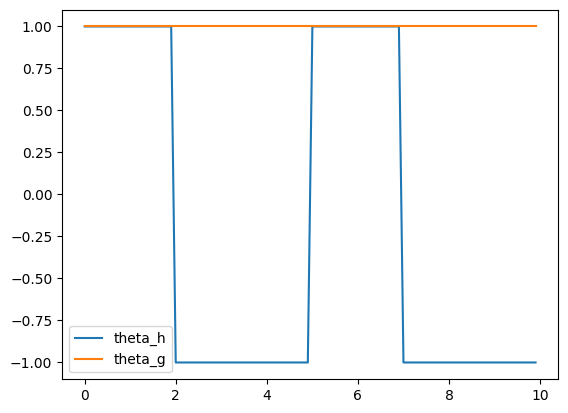

In [4]:
import numpy as np
import matplotlib.pyplot as plt
freq, duty, phase = (0.2, 1), (0.4, 1.0), (0.0, 0.0)
def square_wave(t, freq, duty, phase_in_cycles):
        cycle_position = np.mod(freq * t - phase_in_cycles, 1.0)
        return np.where(cycle_position < duty, 1.0, -1.0)

t = np.arange(0, 10, 0.1)
plt.plot(t, square_wave(t, freq[0], duty[0], phase[0]), label='theta_h') #grid
plt.plot(t, square_wave(t, freq[1], duty[1], phase[1]), label='theta_g')  #hc
plt.legend()

fraction correct = 0.7594444444444445
8 15 18
8 15 18


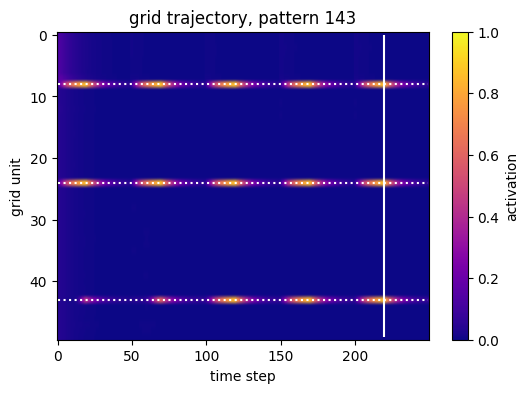

In [8]:
sample_step = compute_sample_step(freq[0], duty[0], phase[0], scaffold.dt, 250)
#sample_step = compute_sample_step(0.2, 0.4, 0.0, scaffold.dt, 250)


g_err = np.max(np.abs(g_traj[sample_step, :, :] - g_true), axis=0)
frac_grid_sig = np.mean(g_err < 0.25, axis=-1)
print('fraction correct =', frac_grid_sig)

patt = 143
print(np.argmax(g_traj[sample_step, :,patt][:9]), np.argmax(g_traj[sample_step, :,patt][9:25]), np.argmax(g_traj[sample_step, :,patt][25:]))

# Get the indices for the horizontal lines
idx1 = np.argmax(g_true[:, patt][:9])
idx2 = np.argmax(g_true[:, patt][9:25]) + 9
idx3 = np.argmax(g_true[:, patt][25:]) + 25

print(idx1, idx2 - 9, idx3 - 25)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(np.asarray(g_traj[:, :, patt]).T, aspect='auto', origin='upper', cmap='plasma', vmin=0, vmax=1)
plt.vlines(sample_step, 0, 49, colors='white')
plt.hlines([idx1, idx2, idx3], 0, 249, colors='white', linestyles='dotted') # Add dotted horizontal lines
ax.set_xlabel('time step')
ax.set_ylabel('grid unit')
ax.set_title(f'grid trajectory, pattern {patt}')
fig.colorbar(im, label='activation')
plt.show()

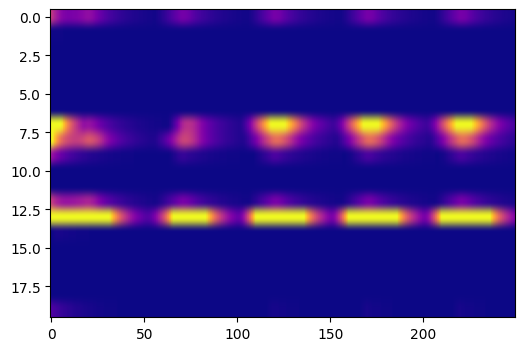

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(np.asarray(h_traj[:, :20, patt]).T, aspect='auto', origin='upper', cmap='plasma', vmin=0, vmax=1)

In [ ]:
where = np.where(g_err > 0.2)
incorrect = g_traj[-1, :, where[0]]
print(where)

(array([1345, 2545]),)


#